In [1]:
import sys

In [2]:
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import interpolate
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
print(torch.__version__)
from datetime import datetime
from torch.utils.data import Dataset, DataLoader, TensorDataset

/home/jonathan/miniconda/envs/torch_fall23/lib/python3.11/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/jonathan/miniconda/envs/torch_fall23/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/home/jonathan/miniconda/envs/torch_fall23/lib/python3.11/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/jonathan/miniconda/envs/torch_fall23/lib/python3.11/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


2.1.0.dev20230830


In [3]:
N = 800
mult = 2*2
span = 2
x = (np.random.rand(mult*N).reshape(-1,2)*2-1)*span/2.0
y = np.sin(1*1*np.pi*x[:,0])*np.sin(2*1*np.pi*x[:,1])

let's test quantization

In [4]:
xc = (x*100).astype('int8')
print(xc)
indexing='xy'
grid_info = np.array([[-50, 50,100] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
print(f)

[[ 67  13]
 [ 70  77]
 [ 42 -78]
 ...
 [ 72  -8]
 [ 21   2]
 [-77  90]]
[[-50 -50]
 [-49 -50]
 [-48 -50]
 ...
 [ 47  49]
 [ 48  49]
 [ 49  49]]


In [5]:
print(f.shape,xc.shape)
xcf = np.matmul(xc,f.T)
cc = np.cos(xcf*np.pi/100)
sc = np.sin(xcf*np.pi/100)
print(cc)
print(sc)
cyc = np.matmul(y,cc)
syc = np.matmul(y,sc)
cyc + 1j*syc

(10000, 2) (1600, 2)
[[-9.92114701e-01 -9.75916762e-01  6.84547106e-01 ... -1.25333234e-01
   9.17754626e-01 -8.09016994e-01]
 [-6.84547106e-01 -9.29776486e-01  2.48689887e-01 ... -9.87688341e-01
   4.53990500e-01  4.53990500e-01]
 [ 9.68583161e-01  6.12323400e-17 -9.68583161e-01 ... -1.87381315e-01
   9.04827052e-01  6.37423990e-01]
 ...
 [-6.37423990e-01 -1.87381315e-01  8.76306680e-01 ... -8.09016994e-01
   9.68583161e-01 -4.25779292e-01]
 [-6.84547106e-01 -9.87688341e-01 -8.76306680e-01 ... -3.38737920e-01
  -8.44327926e-01 -9.95561965e-01]
 [-8.44327926e-01  2.78991106e-01  4.25779292e-01 ...  7.50111070e-01
  -1.25333234e-01 -7.07106781e-01]]
[[ 0.12533323 -0.21814324 -0.72896863 ... -0.9921147   0.39714789
   0.58778525]
 [ 0.72896863  0.36812455 -0.96858316 ...  0.15643447 -0.89100652
   0.89100652]
 [ 0.24868989  1.          0.24868989 ... -0.98228725 -0.42577929
   0.77051324]
 ...
 [ 0.77051324 -0.98228725  0.48175367 ... -0.58778525 -0.24868989
   0.90482705]
 [ 0.72896863 

array([ -4.69510166 -0.74756652j,   4.08041956-16.53722454j,
        13.77024462 -3.27626109j, ...,  -5.97670947 +2.36819356j,
        -7.68229697 -0.4655605j , -16.03710404 -5.46700145j])

In [6]:
print(np.min(cyc))
print(cyc.shape)

-339.21639892016435
(10000,)


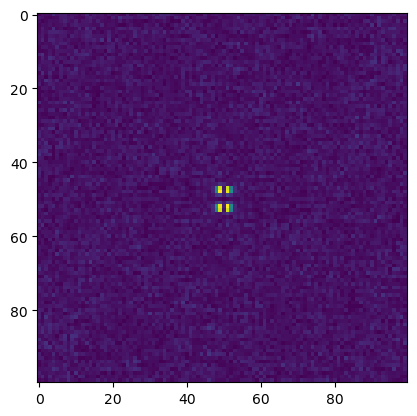

In [7]:
plt.imshow(np.abs(cyc + 1j*syc).reshape(100,100))

That looks reasonable.

Text(0, 0.5, 'y')

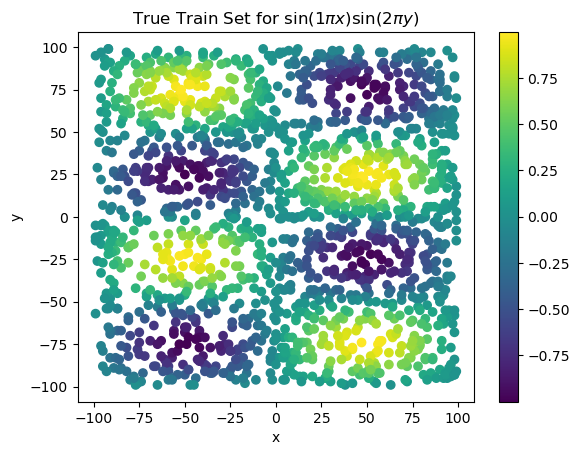

In [8]:
plt.scatter(xc[:,0], xc[:,1], c=y)
plt.colorbar()
plt.title('True Train Set for $\sin(1\pi x)\sin(2\pi y)$')
plt.xlabel('x')
plt.ylabel('y')

In [9]:
xc = (x*128).astype('int8')
print(xc)
indexing='xy'
grid_info = np.array([[-16, 16,32] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
print(f)

[[  86   17]
 [  90   99]
 [  54 -100]
 ...
 [  93  -11]
 [  26    3]
 [ -99  115]]
[[-16 -16]
 [-15 -16]
 [-14 -16]
 ...
 [ 13  15]
 [ 14  15]
 [ 15  15]]


In [10]:
print(f.shape,xc.shape,f.dtype,xc.dtype)
xcf = np.matmul(xc,f.T)
cc = np.cos(xcf*np.pi/128)
sc = np.sin(xcf*np.pi/128)
print(cc)
print(sc)
cyc = np.matmul(y,cc)
syc = np.matmul(y,sc)
cyc + 1j*syc

(1024, 2) (1600, 2) int8 int8
[[-0.92387953  0.80320753  0.09801714 ... -0.65317284 -0.31368174
   0.97570213]
 [ 0.38268343 -0.97003125  0.77301045 ... -0.68954054 -0.17096189
   0.8932243 ]
 [ 0.70710678  0.85772861 -0.29028468 ...  0.74095113  0.83146961
  -0.33688985]
 ...
 [ 0.70710678  0.07356456 -0.80320753 ...  0.88192126 -0.9329928
   0.33688985]
 [ 0.38268343 -0.24298018 -0.77301045 ... -0.99969882 -0.81758481
  -0.31368174]
 [ 1.         -0.75720885  0.14673047 ... -0.24298018 -0.44961133
   0.92387953]]
[[-0.38268343 -0.5956993   0.99518473 ...  0.75720885 -0.94952818
   0.21910124]
 [ 0.92387953 -0.24298018 -0.63439328 ...  0.72424708 -0.98527764
   0.44961133]
 [-0.70710678  0.51410274  0.95694034 ... -0.67155895  0.55557023
   0.94154407]
 ...
 [-0.70710678  0.99729046 -0.5956993  ...  0.47139674  0.35989504
  -0.94154407]
 [ 0.92387953  0.97003125  0.63439328 ...  0.02454123 -0.57580819
  -0.94952818]
 [ 0.         -0.65317284  0.98917651 ... -0.97003125  0.8932243
  -0

array([-25.87095869-18.30229674j,   7.13944839 +7.30589238j,
        44.31668443 +2.54287626j, ..., -20.08915049+16.04114984j,
         9.82148851-20.02491972j,   9.43305806 +0.87920128j])

In [11]:
print(np.min(cyc))
print(cyc.shape)

-420.2098917316713
(1024,)


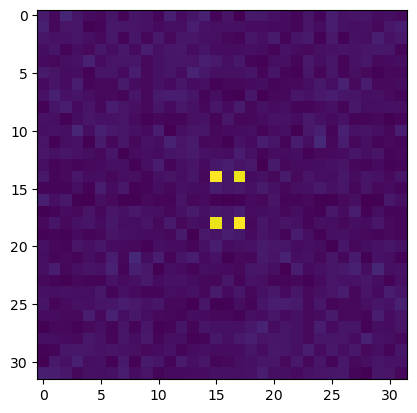

In [12]:
plt.imshow(np.abs(cyc + 1j*syc).reshape(32,32))

Also looks reasonable.

Text(0, 0.5, 'y')

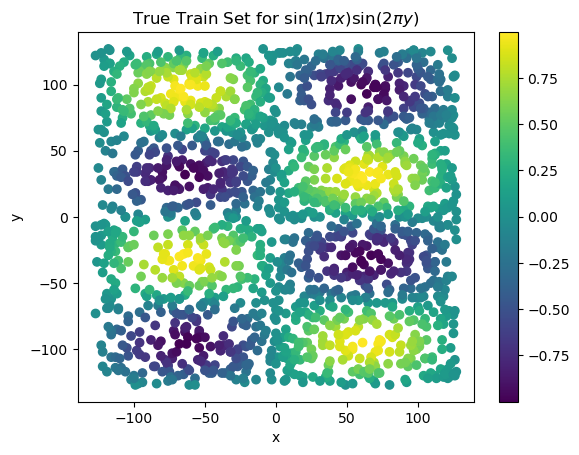

In [13]:
plt.scatter(xc[:,0], xc[:,1], c=y)
plt.colorbar()
plt.title('True Train Set for $\sin(1\pi x)\sin(2\pi y)$')
plt.xlabel('x')
plt.ylabel('y')

In [14]:
xc = (x*8).astype('int8')
print(xc)
indexing='xy'
grid_info = np.array([[-8, 8,16] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
print(f)

[[ 5  1]
 [ 5  6]
 [ 3 -6]
 ...
 [ 5  0]
 [ 1  0]
 [-6  7]]
[[-8 -8]
 [-7 -8]
 [-6 -8]
 [-5 -8]
 [-4 -8]
 [-3 -8]
 [-2 -8]
 [-1 -8]
 [ 0 -8]
 [ 1 -8]
 [ 2 -8]
 [ 3 -8]
 [ 4 -8]
 [ 5 -8]
 [ 6 -8]
 [ 7 -8]
 [-8 -7]
 [-7 -7]
 [-6 -7]
 [-5 -7]
 [-4 -7]
 [-3 -7]
 [-2 -7]
 [-1 -7]
 [ 0 -7]
 [ 1 -7]
 [ 2 -7]
 [ 3 -7]
 [ 4 -7]
 [ 5 -7]
 [ 6 -7]
 [ 7 -7]
 [-8 -6]
 [-7 -6]
 [-6 -6]
 [-5 -6]
 [-4 -6]
 [-3 -6]
 [-2 -6]
 [-1 -6]
 [ 0 -6]
 [ 1 -6]
 [ 2 -6]
 [ 3 -6]
 [ 4 -6]
 [ 5 -6]
 [ 6 -6]
 [ 7 -6]
 [-8 -5]
 [-7 -5]
 [-6 -5]
 [-5 -5]
 [-4 -5]
 [-3 -5]
 [-2 -5]
 [-1 -5]
 [ 0 -5]
 [ 1 -5]
 [ 2 -5]
 [ 3 -5]
 [ 4 -5]
 [ 5 -5]
 [ 6 -5]
 [ 7 -5]
 [-8 -4]
 [-7 -4]
 [-6 -4]
 [-5 -4]
 [-4 -4]
 [-3 -4]
 [-2 -4]
 [-1 -4]
 [ 0 -4]
 [ 1 -4]
 [ 2 -4]
 [ 3 -4]
 [ 4 -4]
 [ 5 -4]
 [ 6 -4]
 [ 7 -4]
 [-8 -3]
 [-7 -3]
 [-6 -3]
 [-5 -3]
 [-4 -3]
 [-3 -3]
 [-2 -3]
 [-1 -3]
 [ 0 -3]
 [ 1 -3]
 [ 2 -3]
 [ 3 -3]
 [ 4 -3]
 [ 5 -3]
 [ 6 -3]
 [ 7 -3]
 [-8 -2]
 [-7 -2]
 [-6 -2]
 [-5 -2]
 [-4 -2]
 [-3 -2]
 [-2 -2]
 [-1 -2]
 [ 0

In [15]:
print(f.shape,xc.shape,f.dtype,xc.dtype)
xcf = np.matmul(xc,f.T)
cc = np.cos(xcf*np.pi/8)
sc = np.sin(xcf*np.pi/8)
print(cc)
print(sc)
cyc = np.matmul(y,cc)
syc = np.matmul(y,sc)
cyc + 1j*syc

(256, 2) (1600, 2) int8 int8
[[ 1.00000000e+00 -3.82683432e-01 -7.07106781e-01 ...  1.00000000e+00
  -3.82683432e-01 -7.07106781e-01]
 [-1.00000000e+00  3.82683432e-01  7.07106781e-01 ...  3.82683432e-01
  -1.00000000e+00  3.82683432e-01]
 [-1.00000000e+00 -3.82683432e-01  7.07106781e-01 ... -3.82683432e-01
  -1.00000000e+00 -3.82683432e-01]
 ...
 [-1.00000000e+00  3.82683432e-01  7.07106781e-01 ... -9.23879533e-01
   7.07106781e-01  3.82683432e-01]
 [-1.00000000e+00 -9.23879533e-01 -7.07106781e-01 ... -3.82683432e-01
  -7.07106781e-01 -9.23879533e-01]
 [-1.00000000e+00  7.07106781e-01  3.06161700e-16 ...  3.82683432e-01
   3.82683432e-01 -9.23879533e-01]]
[[ 7.34788079e-16  9.23879533e-01 -7.07106781e-01 ... -4.89858720e-16
   9.23879533e-01 -7.07106781e-01]
 [-4.89982516e-15 -9.23879533e-01  7.07106781e-01 ...  9.23879533e-01
   1.10218212e-15 -9.23879533e-01]
 [ 3.67394040e-16 -9.23879533e-01 -7.07106781e-01 ...  9.23879533e-01
  -3.67394040e-16 -9.23879533e-01]
 ...
 [-6.12323400e-

array([-1.08428658e+01+1.79640107e-14j,  1.32799358e+00+3.13739072e+01j,
        1.23590570e+01+7.99523499e-01j, -3.17362886e+00-6.99001491e+00j,
        6.46480557e+00-7.00942803e+00j,  2.08251399e+01+1.94412922e+00j,
        2.99000598e+00+7.46410824e+00j, -8.54149164e+00+2.93398971e+00j,
       -1.19088454e+01-1.51348836e-14j, -8.54149164e+00-2.93398971e+00j,
        2.99000598e+00-7.46410824e+00j,  2.08251399e+01-1.94412922e+00j,
        6.46480557e+00+7.00942803e+00j, -3.17362886e+00+6.99001491e+00j,
        1.23590570e+01-7.99523499e-01j,  1.32799358e+00-3.13739072e+01j,
        1.93673707e+01-8.99499302e+00j, -1.40995063e+01-1.26856457e+01j,
       -2.16317295e+01-1.08845325e+01j, -3.82922884e+00-1.71605100e+00j,
        2.15713893e-01+1.54039846e+01j, -1.27732011e+01+1.03496540e+01j,
       -1.13846037e+01-1.07882287e+00j, -6.15216205e+00-4.77463344e+00j,
        7.88524807e+00-1.75361406e+01j,  1.45916842e+01-2.27862378e+00j,
        1.09002781e+01+9.41333253e+00j,  1.19876261

In [16]:
print(np.min(cyc))
print(cyc.shape)

-379.6408375952207
(256,)


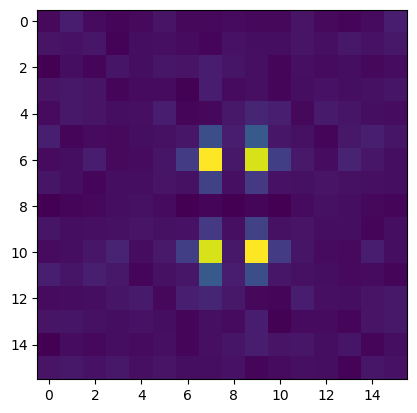

In [17]:
plt.imshow(np.abs(cyc + 1j*syc).reshape(16,16))

Also looks reasonable.

In [18]:
y1 = np.sin(1*1*np.pi*x[:,0])*np.sin(2*1*np.pi*x[:,1])
y2 = np.sin(4*1*np.pi*x[:,0])*np.sin(2*1*np.pi*x[:,1])
y3 = np.sin(2*1*np.pi*x[:,0])*np.sin(4*1*np.pi*x[:,1])
y4 = np.sin(3*1*np.pi*x[:,0])*np.sin(6*1*np.pi*x[:,1])
y5 = np.sin(4*1*np.pi*x[:,0])*np.sin(8*1*np.pi*x[:,1])

#yd = np.sin(2.8*1*np.pi*y1)*np.sin(5.3*1*np.pi*y2)
yd = np.sin(2*1*np.pi*y1)

# this seems very complicated, let's try something easier first
#yd = y1/5 + 0*y2/5 + y3/5 + y4/5 + y5/5
# this doesn't converge as well, maybe the above is better?

Text(0, 0.5, 'y')

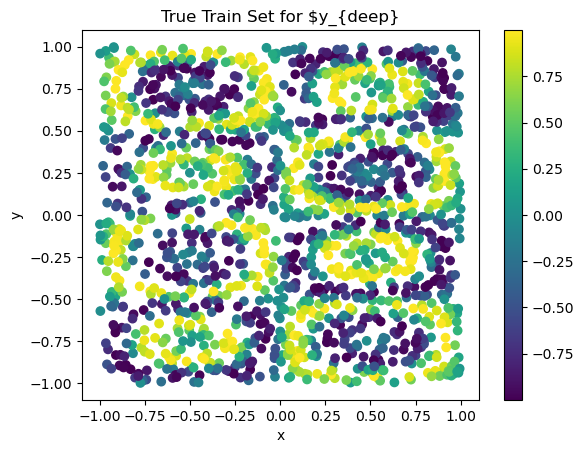

In [19]:
plt.scatter(x[:,0], x[:,1], c=yd)
plt.colorbar()
plt.title('True Train Set for $y_{deep}')
plt.xlabel('x')
plt.ylabel('y')

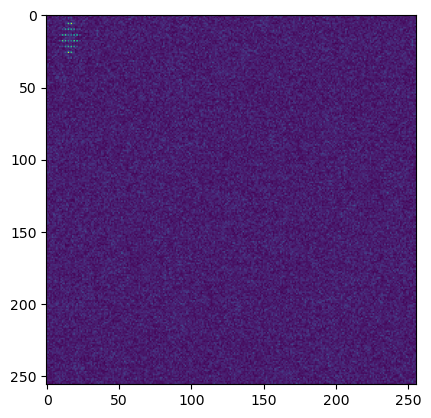

In [20]:
xc = (x*128).astype('int8')
#print(xc)
indexing='xy'
grid_info = np.array([[-16, 16,256] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xt,(NN,1)) for xt in ff]
f = np.hstack(np.array(fff))
#print(f)
xcf = np.matmul(x,f.T)
cc = np.cos(xcf*np.pi)
sc = np.sin(xcf*np.pi)
cyc = np.matmul(yd,cc)
syc = np.matmul(yd,sc)
cyc + 1j*syc
plt.imshow((np.abs(cyc + 1j*syc)).reshape(256,256))

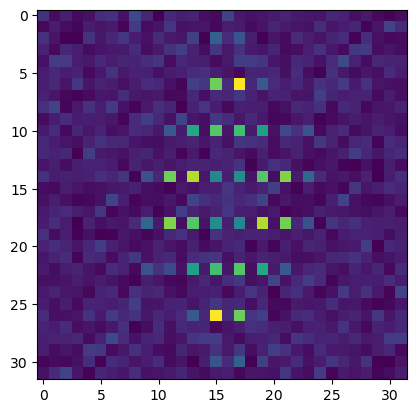

In [21]:
plt.imshow((np.abs(cyc + 1j*syc)).reshape(256,256)[:32,:32])

In [22]:
xt = (np.random.rand(mult*N*N).reshape(-1,2)*2-1)*span/2.0
y1t = np.sin(1*1*np.pi*xt[:,0])*np.sin(2*1*np.pi*xt[:,1])
y2t = np.sin(4*1*np.pi*xt[:,0])*np.sin(2*1*np.pi*xt[:,1])
y3t = np.sin(2*1*np.pi*xt[:,0])*np.sin(4*1*np.pi*xt[:,1])
y4t = np.sin(3*1*np.pi*xt[:,0])*np.sin(6*1*np.pi*xt[:,1])
y5t = np.sin(4*1*np.pi*xt[:,0])*np.sin(8*1*np.pi*xt[:,1])
#ydt = np.sin(2.8*1*np.pi*y1t)*np.sin(5.3*1*np.pi*y2t)
ydt = np.sin(2.*1*np.pi*y1t)

# this seems very complicated, let's try something easier first
#ydt = y1t/5 + 0*y2t/5 + y3t/5 + y4t/5 + y5t/5
# this doesn't converge as well, maybe the above is better?

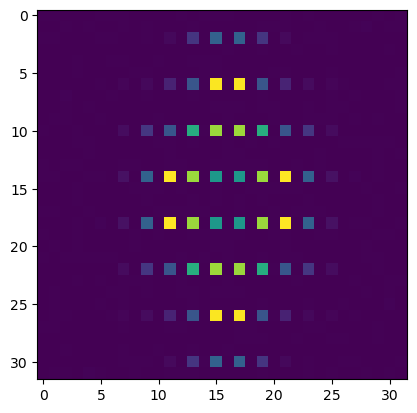

In [23]:
xtc = (xt*128).astype('int8')
#print(xc)
indexing='xy'
grid_info = np.array([[-16, 16,32] for j in np.arange(2)])
ff = [np.arange(grid_info[i,0], grid_info[i,1], (grid_info[i,1]-grid_info[i,0])/grid_info[i,2], dtype='int8') for i in np.arange(grid_info.shape[0])]
ff = np.meshgrid(*ff, indexing=indexing)
dd = len(ff)
NN = ff[0].size
fff = [np.reshape(xxt,(NN,1)) for xxt in ff]
f = np.hstack(np.array(fff))
#print(f)
xcf = np.matmul(xt,f.T)
cc = np.cos(xcf*np.pi)
sc = np.sin(xcf*np.pi)
cyc = np.matmul(ydt,cc)
syc = np.matmul(ydt,sc)
cyc + 1j*syc
plt.imshow((np.abs(cyc + 1j*syc)).reshape(32,32))

Text(0, 0.5, 'y')

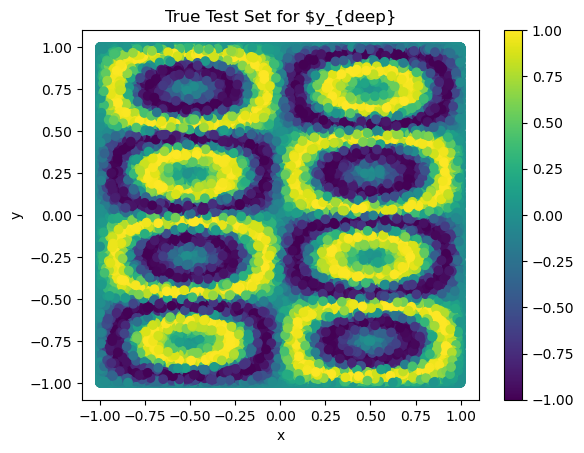

In [24]:
plt.scatter(xt[:,0], xt[:,1], c=ydt)
plt.colorbar()
plt.title('True Test Set for $y_{deep}')
plt.xlabel('x')
plt.ylabel('y')

In [44]:
MM=80
NN=80
print(2/3,1/3)
ss = [.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33,-.33]
bs = [-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66,-.66,.66]
trues_wh = np.array([ss,bs])

0.6666666666666666 0.3333333333333333


In [45]:
print(trues_wh.shape)

(2, 80)


In [46]:

class ShallowRegressor(nn.Module):
    def __init__(self):
        super(ShallowRegressor,self).__init__()
        self.fc1 = nn.Linear(2,MM)
        self.fc2 = nn.Linear(MM,NN)        
        self.fc3 = nn.Linear(NN,1)     
        self.fc1.weight = torch.nn.Parameter(torch.Tensor(trues_wh.T))
        #self.fc1.bias = torch.nn.Parameter(torch.Tensor(tv*zv))      
        #self.fc2.bias = torch.nn.Parameter(torch.Tensor(np.array([np.mean(y)])))
        #self.fc2.weight = torch.nn.Parameter(torch.Tensor((sne)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))        
        x = self.fc3(x)
        return x

In [47]:
model = ShallowRegressor()
criterion = nn.MSELoss()  # mean square error
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr=0.0001)

In [48]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float('inf')

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [49]:
tensor_x = torch.Tensor(x) # transform to torch tensor
tensor_y = torch.Tensor(yd.reshape(-1,1))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')
model=model.to(device)
tensor_x=tensor_x.to(device)
tensor_y=tensor_y.to(device)
early_stopper = EarlyStopper(patience=8, min_delta=.001)
for epoch in range(40000):  # loop over the dataset multiple times


    # zero the parameter gradients
    optimizer.zero_grad()

    # forward + backward + optimize
    outputs = model(tensor_x)
    loss = criterion(outputs, tensor_y)
    loss.backward()
    optimizer.step()
    # print statistics
    with torch.no_grad(): 
        outputs = model(torch.Tensor(xt))
        vloss = criterion(outputs, torch.Tensor(ydt.reshape(-1,1)))    
    if epoch%500==0:
        print(f'[{epoch + 1}] loss: {loss.item():.3f} vloss: {vloss.item():.3f}')
    if early_stopper.early_stop(vloss):             
        break
print('Finished Training')

[1] loss: 0.480 vloss: 0.480
[501] loss: 0.436 vloss: 0.448
[1001] loss: 0.375 vloss: 0.398
[1501] loss: 0.341 vloss: 0.372
[2001] loss: 0.312 vloss: 0.349
[2501] loss: 0.284 vloss: 0.325
[3001] loss: 0.256 vloss: 0.300
[3501] loss: 0.233 vloss: 0.279
[4001] loss: 0.213 vloss: 0.261
[4501] loss: 0.195 vloss: 0.244
[5001] loss: 0.179 vloss: 0.230
[5501] loss: 0.166 vloss: 0.216
[6001] loss: 0.155 vloss: 0.205
[6501] loss: 0.144 vloss: 0.194
[7001] loss: 0.134 vloss: 0.185
[7501] loss: 0.127 vloss: 0.177
[8001] loss: 0.120 vloss: 0.169
[8501] loss: 0.114 vloss: 0.163
[9001] loss: 0.108 vloss: 0.157
[9501] loss: 0.103 vloss: 0.151
[10001] loss: 0.099 vloss: 0.146
[10501] loss: 0.094 vloss: 0.142
[11001] loss: 0.090 vloss: 0.137
[11501] loss: 0.087 vloss: 0.133
[12001] loss: 0.083 vloss: 0.129
[12501] loss: 0.080 vloss: 0.126
[13001] loss: 0.077 vloss: 0.123
[13501] loss: 0.075 vloss: 0.120
[14001] loss: 0.072 vloss: 0.117
[14501] loss: 0.070 vloss: 0.114
[15001] loss: 0.068 vloss: 0.112
[

In [50]:
print(tensor_x.shape)
ABS = 60
XX = np.linspace(-1,1,ABS,endpoint=False)
XXg = mt.grid_to_stack(np.meshgrid(XX,XX))
print(XXg.shape)

torch.Size([1600, 2])
(3600, 2)


In [51]:
model.eval()
YYg = model(torch.Tensor(XXg).to(device))

In [52]:
y1g = np.sin(1*1*np.pi*XXg[:,0])*np.sin(2*1*np.pi*XXg[:,1])
y2g = np.sin(4*1*np.pi*XXg[:,0])*np.sin(2*1*np.pi*XXg[:,1])
y3g = np.sin(2*1*np.pi*XXg[:,0])*np.sin(4*1*np.pi*XXg[:,1])
y4g = np.sin(3*1*np.pi*XXg[:,0])*np.sin(6*1*np.pi*XXg[:,1])
y5g = np.sin(4*1*np.pi*XXg[:,0])*np.sin(8*1*np.pi*XXg[:,1])
#ydg = np.sin(2.8*1*np.pi*y1g)*np.sin(5.3*1*np.pi*y2g)
ydg = np.sin(2*1*np.pi*y1g)

# this seems very complicated, let's try something easier first
#ydg = y1g/5 + 0*y2g/5 + y3g/5 + y4g/5 + y5g/5
# this doesn't converge as well, maybe the above is better?

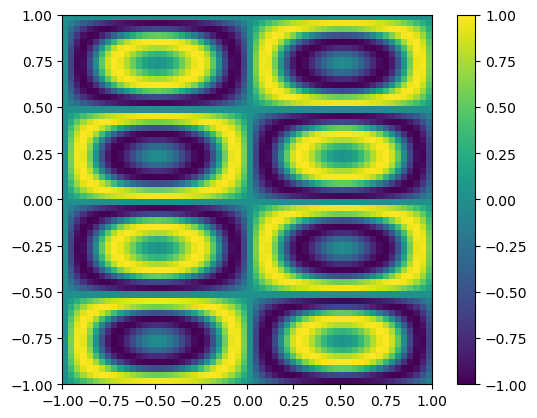

In [53]:
plt.imshow((ydg).reshape(ABS,ABS),extent=[-1, 1, -1, 1])
plt.colorbar()

In [54]:
#print(model.fc1.bias)
#print(model.fc1.weight)
print(model.fc1.weight.detach().numpy())
print(model.fc1.bias.detach().numpy())


[[ 0.769012   -0.97999024]
 [ 0.42884964  0.98792446]
 [ 0.6811549  -1.2404636 ]
 [ 0.6708179   1.0921736 ]
 [ 0.5472405  -1.0854218 ]
 [ 0.38590127  1.0670748 ]
 [ 0.81374365 -0.9543343 ]
 [ 0.77999914  1.6821512 ]
 [ 1.2556834  -1.8979009 ]
 [ 0.88212246  1.0219864 ]
 [ 1.4581501  -1.2872758 ]
 [ 0.6632531   1.006633  ]
 [ 0.8681444  -1.4983175 ]
 [ 0.9973217   1.0463121 ]
 [ 0.9805057  -1.3085746 ]
 [ 1.2196475   1.6493024 ]
 [ 0.9321873  -1.0776372 ]
 [ 0.39425355  2.1197286 ]
 [ 1.2108618  -1.1326349 ]
 [ 1.1785797   0.9091604 ]
 [ 1.3063378  -1.7399344 ]
 [ 1.2063121   1.3055447 ]
 [ 0.74461836 -1.4392984 ]
 [ 1.0297083   1.3696486 ]
 [ 0.5446941  -1.1259317 ]
 [ 0.6321298   0.7463417 ]
 [ 0.6262076  -1.2654802 ]
 [ 1.269746    1.995734  ]
 [ 0.59609354 -1.1872058 ]
 [ 0.6380594   1.3232493 ]
 [ 1.3036073  -1.7203848 ]
 [ 1.3796237   1.7098207 ]
 [ 0.5750649  -1.2281294 ]
 [ 0.46382678  1.0330387 ]
 [ 0.78527296 -2.6243153 ]
 [ 1.1619564   1.2873654 ]
 [ 1.1638135  -1.2475964 ]
 

In [55]:
wh1, wn1 = bounds.nn_wnorm(model.fc1.weight.detach().numpy().T)
print(wh1.shape)
wh2, wn2 = bounds.nn_wnorm(model.fc2.weight.detach().numpy().T)
print(wh2.shape)

(2, 80)
(80, 80)


In [56]:
print(model)
model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(params)

ShallowRegressor(
  (fc1): Linear(in_features=2, out_features=80, bias=True)
  (fc2): Linear(in_features=80, out_features=80, bias=True)
  (fc3): Linear(in_features=80, out_features=1, bias=True)
)
6801


In [57]:
print(wh1.T)
print(wn1)
print((np.abs(np.abs(wh1.T[:,0])-0.33)<.01) )

[[ 0.43968612 -0.5603139 ]
 [ 0.30269444  0.69730556]
 [ 0.3544694  -0.64553064]
 [ 0.3804998   0.6195002 ]
 [ 0.3351829  -0.6648171 ]
 [ 0.2655937   0.73440635]
 [ 0.46024194 -0.539758  ]
 [ 0.3167959   0.68320405]
 [ 0.39817655 -0.6018234 ]
 [ 0.46327317  0.5367269 ]
 [ 0.5311198  -0.46888015]
 [ 0.39718464  0.6028154 ]
 [ 0.36685336 -0.6331467 ]
 [ 0.48801386  0.5119861 ]
 [ 0.42834046 -0.57165956]
 [ 0.42511985  0.5748801 ]
 [ 0.46381527 -0.5361847 ]
 [ 0.15682434  0.8431757 ]
 [ 0.5166902  -0.48330975]
 [ 0.5645242   0.4354759 ]
 [ 0.42883164 -0.5711684 ]
 [ 0.48024717  0.51975286]
 [ 0.34095547 -0.6590445 ]
 [ 0.42916012  0.5708399 ]
 [ 0.32604194 -0.673958  ]
 [ 0.458573    0.541427  ]
 [ 0.33103117 -0.66896886]
 [ 0.38883898  0.61116093]
 [ 0.33426443 -0.66573554]
 [ 0.32532325  0.6746767 ]
 [ 0.4310882  -0.5689118 ]
 [ 0.4465604   0.55343956]
 [ 0.31891453 -0.6810854 ]
 [ 0.30986536  0.69013464]
 [ 0.23031312 -0.7696868 ]
 [ 0.47439927  0.5256008 ]
 [ 0.48262784 -0.5173722 ]
 

In [58]:
print(wh2)
print(wn2)

[[ 0.00195634 -0.01741309  0.03217639 ... -0.02399902 -0.00949224
  -0.00474087]
 [-0.01777386 -0.01518813 -0.00252239 ...  0.00212896 -0.00377735
  -0.01321764]
 [-0.00872779  0.0168046   0.00785019 ... -0.01288754 -0.00821596
   0.00426213]
 ...
 [-0.02254291 -0.01196425 -0.00324557 ... -0.010218    0.020542
  -0.02049494]
 [-0.01423245 -0.01580365 -0.00688585 ...  0.00691618 -0.0213853
   0.00244178]
 [-0.00127614 -0.01512113  0.00062042 ...  0.02044717 -0.02247101
  -0.00543996]]
[ 4.814014   4.887666  17.95208   29.264534  11.387582  18.721855
 28.3875    35.401474  14.652296  35.911312  29.254631  14.230211
 25.115337  42.24305   32.84621   34.39331   22.49185   30.251108
 13.113337  32.01538   21.98466   36.53398   27.0101    23.739475
 19.586498  12.813009   4.730815  21.114649  19.051765  17.868113
  4.2465687 33.704926  31.911259  34.79394    4.6571574 32.08961
 24.477142  13.702047  19.053211  29.820293  11.952088  17.357445
 21.745628  17.615005  37.751705  38.95104   28.24

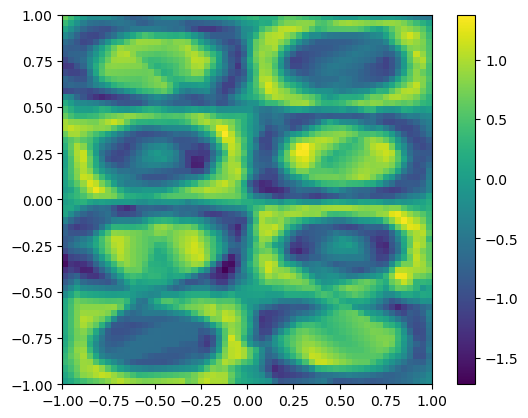

In [59]:
plt.imshow((YYg.detach().numpy()).reshape(ABS,ABS),extent=[-1, 1, -1, 1])
plt.colorbar()

0.6666666666666666
0.3333333333333333


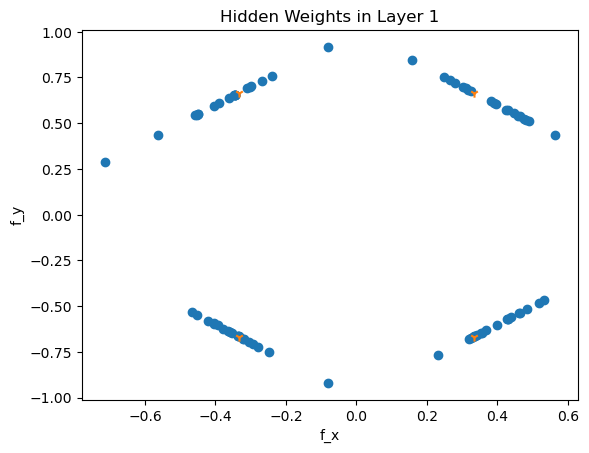

In [60]:
plt.scatter(wh1.T[:,0], wh1.T[:,1])
#plt.scatter([4.1/(4.1+1.2),-4.1/(4.1+1.2),4.1/(4.1+1.2),-4.1/(4.1+1.2),2.1/(2.1+3.4),-2.1/(2.1+3.4),2.1/(2.1+3.4),-2.1/(2.1+3.4)],[1.2/(4.1+1.2),1.2/(4.1+1.2),-1.2/(4.1+1.2),-1.2/(4.1+1.2),3.4/(2.1+3.4),3.4/(2.1+3.4),-3.4/(2.1+3.4),-3.4/(2.1+3.4)])
plt.scatter([1/(1+2),-1/(1+2),1/(1+2),-1/(1+2)],[2/(1+2),2/(1+2),-2/(1+2),-2/(1+2)],marker='1')
plt.title('Hidden Weights in Layer 1')
plt.xlabel('f_x')
plt.ylabel('f_y')
print(2/(2+1))
print(1/(1+2))

(array([10.,  3.,  3.,  6.,  3.,  1., 13.,  2.,  4., 10.]),
 array([-0.56622124, -0.44950056, -0.33277988, -0.21605919, -0.09933851,
         0.01738217,  0.13410285,  0.25082353,  0.36754423,  0.48426491,
         0.60098559]),
 <BarContainer object of 10 artists>)

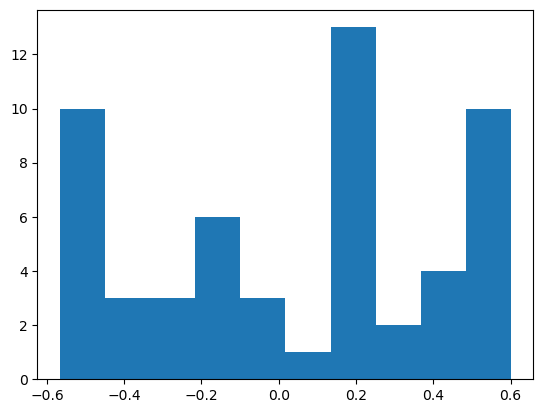

In [61]:
plt.hist((model.fc1.bias.detach().numpy()/wn1)[(np.abs(np.abs(wh1.T[:,0])-0.33)<.1) ])


In [62]:
print(wh2.T[:,(np.abs(np.abs(wh1.T[:,0])-0.38)<.01)])
print(wh2.shape)
print(wh2.T[:,~(np.abs(np.abs(wh1.T[:,0])-0.38)<.01)])
print(wn2)

[[-0.01244694 -0.02238302 -0.01884039 -0.01423245]
 [-0.02125194 -0.00667407  0.01223457 -0.01580365]
 [-0.04837541  0.00887532 -0.00541967 -0.00688585]
 [ 0.00778503  0.00620445  0.00847067 -0.03276356]
 [ 0.00633863  0.0153037  -0.00792795 -0.01006296]
 [ 0.00406709 -0.00108494  0.01212393  0.01834523]
 [-0.01459209 -0.0040713  -0.0039951  -0.00968221]
 [ 0.0091937   0.00687772  0.02226179  0.00428659]
 [-0.00025833 -0.00151675  0.01475992  0.01507058]
 [-0.00736953 -0.01679543 -0.0121978   0.0087407 ]
 [-0.02538594 -0.00045602 -0.06511284  0.00316682]
 [ 0.00112435 -0.00501771  0.00353955  0.01912487]
 [-0.01002119 -0.00363473 -0.00081742 -0.0078975 ]
 [ 0.00913493  0.01187403 -0.03666858  0.03159827]
 [ 0.00476551  0.00111054 -0.024678    0.00044237]
 [ 0.00434251  0.01135485  0.0210047   0.00645845]
 [-0.02303711 -0.04015287  0.06768973  0.0143044 ]
 [ 0.00575016  0.00629633  0.02733632 -0.0136619 ]
 [ 0.00237312 -0.01183402  0.01691622  0.0109003 ]
 [-0.00497124  0.00133853  0.00